In [68]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [69]:
df = pd.read_csv("../../data/raw/diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [70]:
batch_size = len(df) // 10

batches = []

for i in range(10):

    start = i * batch_size

    if i == 9:
        batch = df.iloc[start:]

    else:
        batch = df.iloc[start:start + batch_size]

    batches.append(batch)

print("Number of batches:", len(batches))

Number of batches: 10


In [71]:
results = []
all_true = []
all_pred = []
all_future = []

for i in range(3, 8):

    train_batches = batches[:i]
    future_batch = batches[i]

    train_df = pd.concat(train_batches)

    X_train = train_df.drop("Outcome", axis=1)
    y_train = train_df["Outcome"]

    X_future = future_batch.drop("Outcome", axis=1)
    y_future = future_batch["Outcome"]

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_future = scaler.transform(X_future)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=30,
        verbose=0
    )

    y_prob = model.predict(
        X_future,
        verbose=0
    ).flatten()

    thresholds = [0.3,0.4,0.5,0.6,0.7]

    best_f1 = 0
    best_threshold = 0.5

    for threshold in thresholds:

        y_pred = (y_prob > threshold).astype(int)

        current_f1 = f1_score(
            y_future,
            y_pred,
            zero_division=0
        )

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    y_pred = (y_prob > best_threshold).astype(int)

    all_true.extend(y_future.tolist())
    all_pred.extend(y_pred.tolist())
    all_future.append(future_batch.reset_index(drop=True))

    acc = accuracy_score(y_future, y_pred)
    precision = precision_score(y_future, y_pred, zero_division=0)
    recall = recall_score(y_future, y_pred, zero_division=0)
    f1 = f1_score(y_future, y_pred, zero_division=0)

    results.append([
        i,
        acc,
        precision,
        recall,
        f1,
        best_threshold
    ])

    print(results)
    print(len(results))

[[3, 0.618421052631579, 0.5106382978723404, 0.8, 0.6233766233766234, 0.4]]
1
[[3, 0.618421052631579, 0.5106382978723404, 0.8, 0.6233766233766234, 0.4], [4, 0.6710526315789473, 0.5428571428571428, 0.6785714285714286, 0.6031746031746031, 0.4]]
2
[[3, 0.618421052631579, 0.5106382978723404, 0.8, 0.6233766233766234, 0.4], [4, 0.6710526315789473, 0.5428571428571428, 0.6785714285714286, 0.6031746031746031, 0.4], [5, 0.7105263157894737, 0.6129032258064516, 0.6551724137931034, 0.6333333333333333, 0.4]]
3
[[3, 0.618421052631579, 0.5106382978723404, 0.8, 0.6233766233766234, 0.4], [4, 0.6710526315789473, 0.5428571428571428, 0.6785714285714286, 0.6031746031746031, 0.4], [5, 0.7105263157894737, 0.6129032258064516, 0.6551724137931034, 0.6333333333333333, 0.4], [6, 0.7105263157894737, 0.3333333333333333, 0.5714285714285714, 0.42105263157894735, 0.5]]
4
[[3, 0.618421052631579, 0.5106382978723404, 0.8, 0.6233766233766234, 0.4], [4, 0.6710526315789473, 0.5428571428571428, 0.6785714285714286, 0.6031746031

In [72]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Window",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "Threshold"

    ]

)

results_df

,Window,Accuracy,Precision,Recall,F1,Threshold
0,3,0.618421,0.510638,0.800000,0.623377,0.4
1,4,0.671053,0.542857,0.678571,0.603175,0.4
2,5,0.710526,0.612903,0.655172,0.633333,0.4
3,6,0.710526,0.333333,0.571429,0.421053,0.5
4,7,0.723684,0.529412,0.782609,0.631579,0.4


In [73]:
print(len(results_df))

5


In [74]:
os.makedirs(
    "../results/week5",
    exist_ok=True
)

In [75]:
results_df.to_csv(

    "../results/week5/proactive_results.csv",

    index=False

)

print("CSV Saved")

CSV Saved


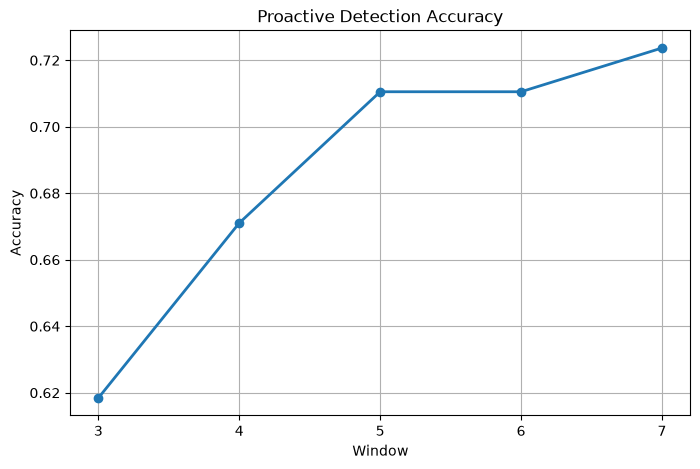

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection Accuracy"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "Accuracy"
)

plt.savefig(
    "../results/week5/proactive_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

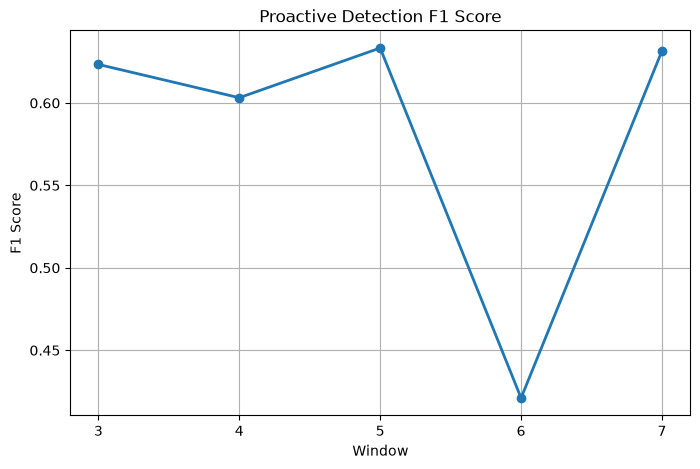

In [77]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["F1"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection F1 Score"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "F1 Score"
)

plt.savefig(
    "../results/week5/proactive_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
print(results_df)
import pandas as pd
import os

future_df = pd.concat(
    all_future,
    ignore_index=True
)

future_df["Actual"] = all_true
future_df["Predicted"] = all_pred

os.makedirs("../results/week6", exist_ok=True)

future_df.to_csv(
    "../results/week6/proactive_predictions.csv",
    index=False
)

print("Saved proactive_predictions.csv")

   Window  Accuracy  Precision    Recall        F1  Threshold
0       3  0.618421   0.510638  0.800000  0.623377        0.4
1       4  0.671053   0.542857  0.678571  0.603175        0.4
2       5  0.710526   0.612903  0.655172  0.633333        0.4
3       6  0.710526   0.333333  0.571429  0.421053        0.5
4       7  0.723684   0.529412  0.782609  0.631579        0.4
Saved proactive_predictions.csv
